## 1. Data Loading and Preprocessing
We load the MNIST dataset, normalize the pixel values to the [0, 1] range, and prepare versions for both Dense and CNN architectures.

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Load dataset - Fixed method name from load_dataset to load_data
(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = tf.keras.datasets.mnist.load_data()

# Normalize pixel values
x_train = x_train_raw.astype('float32') / 255.0
x_test = x_test_raw.astype('float32') / 255.0

# Prepare data for Dense Networks (Flattened)
x_train_flat = x_train.reshape((-1, 784))
x_test_flat = x_test.reshape((-1, 784))

# Prepare data for CNNs (Reshaped with channel dimension)
x_train_cnn = x_train.reshape((-1, 28, 28, 1))
x_test_cnn = x_test.reshape((-1, 28, 28, 1))

# One-hot encode labels
y_train = tf.keras.utils.to_categorical(y_train_raw, 10)
y_test = tf.keras.utils.to_categorical(y_test_raw, 10)

print(f"Training shape: {x_train_raw.shape}")
print(f"Test shape: {x_test_raw.shape}")

I0000 00:00:1778385297.637005   18239 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778385297.714224   18239 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778385300.143690   18239 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Training shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


## 2. Model Architectures


In [2]:
def build_baseline_model():
    model = models.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

def build_dropout_model():
    model = models.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(10, activation='softmax')
    ])
    return model

def build_cnn_model():
    model = models.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])
    return model

## 3. Training Configuration
We use the Adam optimizer and Categorical Cross-entropy as specified.

In [3]:
def compile_and_train(model, train_data, train_labels, epochs=20):
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)

    history = model.fit(
        train_data, train_labels,
        epochs=epochs,
        batch_size=128,
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=1
    )
    return history

print("Training Model 1: Baseline Dense...")
model1 = build_baseline_model()
hist1 = compile_and_train(model1, x_train_flat, y_train)

print("\nTraining Model 2: Dense with Dropout...")
model2 = build_dropout_model()
hist2 = compile_and_train(model2, x_train_flat, y_train)

print("\nTraining Model 3: CNN...")
model3 = build_cnn_model()
hist3 = compile_and_train(model3, x_train_cnn, y_train)

Training Model 1: Baseline Dense...


E0000 00:00:1778385303.309698   18239 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/20


W0000 00:00:1778385303.443272   18239 cpu_allocator_impl.cc:82] Allocation of 150528000 exceeds 10% of free system memory.


375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.8966 - loss: 0.3699 - val_accuracy: 0.9486 - val_loss: 0.1797
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9554 - loss: 0.1533 - val_accuracy: 0.9607 - val_loss: 0.1345
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9692 - loss: 0.1061 - val_accuracy: 0.9687 - val_loss: 0.1071
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9766 - loss: 0.0796 - val_accuracy: 0.9696 - val_loss: 0.1014
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9814 - loss: 0.0625 - val_accuracy: 0.9723 - val_loss: 0.0933
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9852 - loss: 0.0494 - val_accuracy: 0.9737 - val_loss: 0.0874
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9881 - loss: 0.0401 - val_accuracy: 0.9731 - val_loss: 0.0923
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9901 - loss: 0.0324 - val_accuracy: 0.9695 - val_

W0000 00:00:1778385321.288431   18239 cpu_allocator_impl.cc:82] Allocation of 150528000 exceeds 10% of free system memory.


375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.8498 - loss: 0.5034 - val_accuracy: 0.9458 - val_loss: 0.1924
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9338 - loss: 0.2251 - val_accuracy: 0.9589 - val_loss: 0.1418
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9518 - loss: 0.1675 - val_accuracy: 0.9639 - val_loss: 0.1180
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9605 - loss: 0.1363 - val_accuracy: 0.9676 - val_loss: 0.1043
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9656 - loss: 0.1149 - val_accuracy: 0.9705 - val_loss: 0.1011
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9689 - loss: 0.1006 - val_accuracy: 0.9722 - val_loss: 0.0967
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9729 - loss: 0.0911 - val_accuracy: 0.9739 - val_loss: 0.0842
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9746 - loss: 0.0816 - val_accuracy: 0.9747 - val_

W0000 00:00:1778385359.047696   18239 cpu_allocator_impl.cc:82] Allocation of 150528000 exceeds 10% of free system memory.


375/375 ━━━━━━━━━━━━━━━━━━━━ 24s 58ms/step - accuracy: 0.8881 - loss: 0.3673 - val_accuracy: 0.9753 - val_loss: 0.0829
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 19s 52ms/step - accuracy: 0.9633 - loss: 0.1243 - val_accuracy: 0.9822 - val_loss: 0.0614
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.9723 - loss: 0.0904 - val_accuracy: 0.9836 - val_loss: 0.0529
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 17s 46ms/step - accuracy: 0.9772 - loss: 0.0753 - val_accuracy: 0.9877 - val_loss: 0.0441
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 15s 40ms/step - accuracy: 0.9811 - loss: 0.0626 - val_accuracy: 0.9880 - val_loss: 0.0424
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - accuracy: 0.9847 - loss: 0.0511 - val_accuracy: 0.9877 - val_loss: 0.0432
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 20s 52ms/step - accuracy: 0.9851 - loss: 0.0503 - val_accuracy: 0.9873 - val_loss: 0.0442
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 21s 56ms/step - accuracy: 0.9864 - loss: 0.0442 - val_accurac

## 4. Evaluation and Analysis


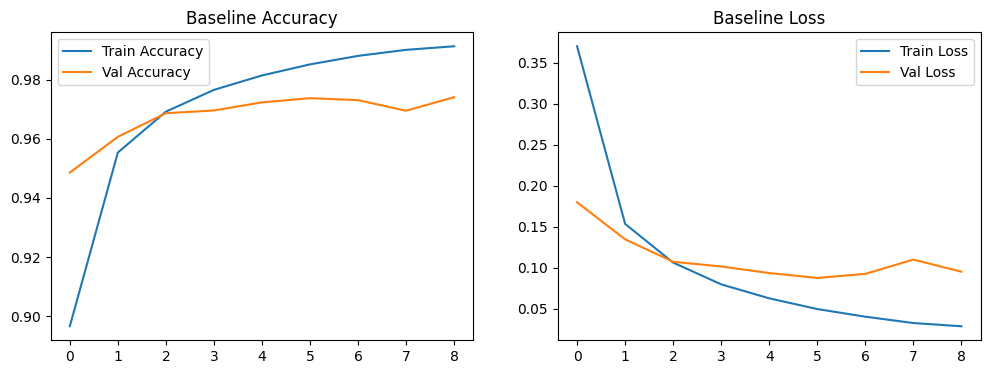

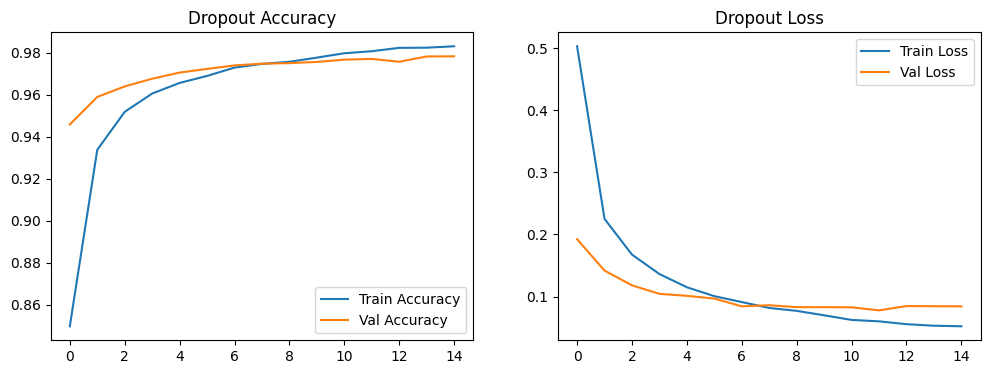

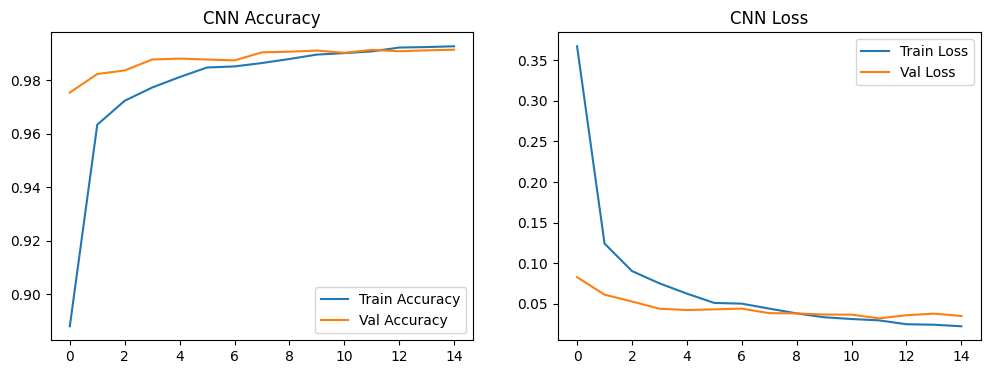

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


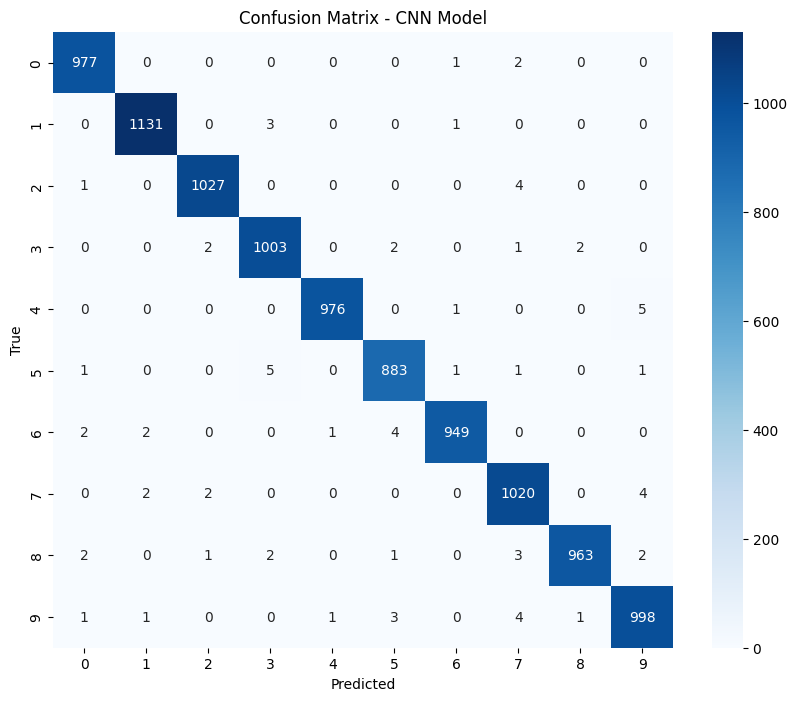

In [4]:
def plot_results(history, title):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title(f'{title} Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'{title} Loss')
    plt.legend()
    plt.show()

plot_results(hist1, "Baseline")
plot_results(hist2, "Dropout")
plot_results(hist3, "CNN")

# Evaluate models on test set
test_loss1, acc1 = model1.evaluate(x_test_flat, y_test, verbose=0)
test_loss2, acc2 = model2.evaluate(x_test_flat, y_test, verbose=0)
test_loss3, acc3 = model3.evaluate(x_test_cnn, y_test, verbose=0)

# Confusion Matrix for CNN (Model 3)
y_pred = model3.predict(x_test_cnn)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - CNN Model')
plt.show()

## 5. Model Performance Comparison Table
Summary of test metrics for all three evaluated architectures.

In [5]:
import pandas as pd
import time

def get_summary(model, history, name, test_data, test_labels):
    test_loss, test_acc = model.evaluate(test_data, test_labels, verbose=0)
    train_acc = history.history['accuracy'][-1]
    params = model.count_params()
    return [name, model.name, train_acc, test_acc, params]

data = [
    ['Model 1', 'Baseline Dense', hist1.history['accuracy'][-1], acc1, model1.count_params()],
    ['Model 2', 'Dense with Dropout', hist2.history['accuracy'][-1], acc2, model2.count_params()],
    ['Model 3', 'CNN', hist3.history['accuracy'][-1], acc3, model3.count_params()]
]

comparison_df = pd.DataFrame(data, columns=['Models', 'Architecture', 'Training Accuracy', 'Test Accuracy', 'Parameters'])
display(comparison_df)

,Models,Architecture,Training Accuracy,Test Accuracy,Parameters
0,Model 1,Baseline Dense,0.991313,0.9758,109386
1,Model 2,Dense with Dropout,0.983021,0.9776,109386
2,Model 3,CNN,0.992604,0.9927,225034


In [6]:
print(f"Baseline Model Final Validation Accuracy: {hist1.history['val_accuracy'][-1]:.4f}")
print(f"Dropout Model Final Validation Accuracy: {hist2.history['val_accuracy'][-1]:.4f}")
print(f"CNN Model Final Validation Accuracy: {hist3.history['val_accuracy'][-1]:.4f}")

Baseline Model Final Validation Accuracy: 0.9741
Dropout Model Final Validation Accuracy: 0.9783
CNN Model Final Validation Accuracy: 0.9913
